In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [19]:
np.random.seed(42)

n = 10000

data = pd.DataFrame({
    "GRE_Score": np.random.randint(260,341,n),
    "TOEFL_Score": np.random.randint(80,121,n),
    "University_Rating": np.random.randint(1,6,n),
    "SOP": np.round(np.random.uniform(1,5,n),1),
    "LOR": np.round(np.random.uniform(1,5,n),1),
    "CGPA": np.round(np.random.uniform(6,10,n),2),
    "Research": np.random.randint(0,2,n),
    "IELTS": np.round(np.random.uniform(5.5,9,n),1),
    "Internship": np.random.randint(0,5,n),
    "Work_Experience": np.random.randint(0,6,n),
    "Projects": np.random.randint(1,8,n)
})

chance = (
    0.003*(data["GRE_Score"]-260)+
    0.004*(data["TOEFL_Score"]-80)+
    0.06*data["CGPA"]+
    0.02*data["Research"]+
    0.01*data["University_Rating"]+
    0.01*data["Projects"]+
    np.random.normal(0,0.03,n)
)

chance=(chance-chance.min())/(chance.max()-chance.min())

data["Chance_of_Admit"]=chance.round(2)

data.to_csv("graduate_admission_10000.csv",index=False)

data.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,IELTS,Internship,Work_Experience,Projects,Chance_of_Admit
0,311,85,2,1.5,3.6,9.06,0,8.8,3,0,7,0.54
1,274,117,3,2.9,4.1,8.01,0,7.0,1,2,3,0.46
2,331,105,3,2.1,2.0,7.85,0,7.3,0,4,6,0.65
3,320,90,2,4.6,2.7,6.93,0,7.0,3,3,3,0.40
4,280,105,3,1.7,1.6,9.41,0,9.0,4,4,5,0.51


In [20]:
df=pd.read_csv("graduate_admission_10000.csv")

df.head()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,IELTS,Internship,Work_Experience,Projects,Chance_of_Admit
0,311,85,2,1.5,3.6,9.06,0,8.8,3,0,7,0.54
1,274,117,3,2.9,4.1,8.01,0,7.0,1,2,3,0.46
2,331,105,3,2.1,2.0,7.85,0,7.3,0,4,6,0.65
3,320,90,2,4.6,2.7,6.93,0,7.0,3,3,3,0.40
4,280,105,3,1.7,1.6,9.41,0,9.0,4,4,5,0.51


In [21]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE_Score          10000 non-null  int64  
 1   TOEFL_Score        10000 non-null  int64  
 2   University_Rating  10000 non-null  int64  
 3   SOP                10000 non-null  float64
 4   LOR                10000 non-null  float64
 5   CGPA               10000 non-null  float64
 6   Research           10000 non-null  int64  
 7   IELTS              10000 non-null  float64
 8   Internship         10000 non-null  int64  
 9   Work_Experience    10000 non-null  int64  
 10  Projects           10000 non-null  int64  
 11  Chance_of_Admit    10000 non-null  float64
dtypes: float64(5), int64(7)
memory usage: 937.6 KB


,0
GRE_Score,0
TOEFL_Score,0
University_Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
IELTS,0
Internship,0
Work_Experience,0


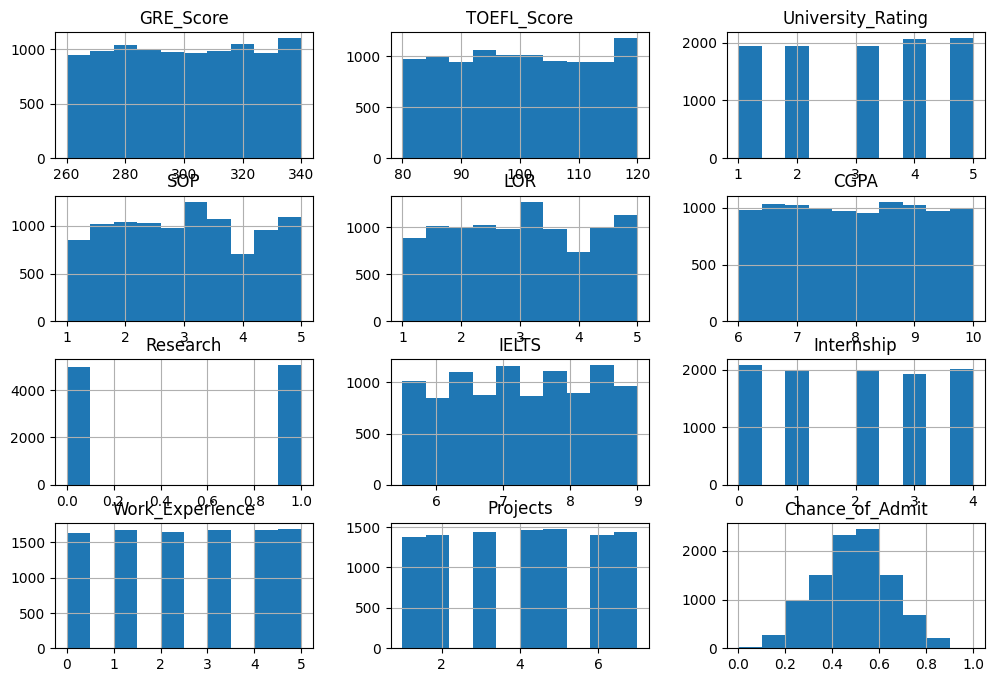

In [22]:
#Histogram
df.hist(figsize=(12,8))
plt.show()

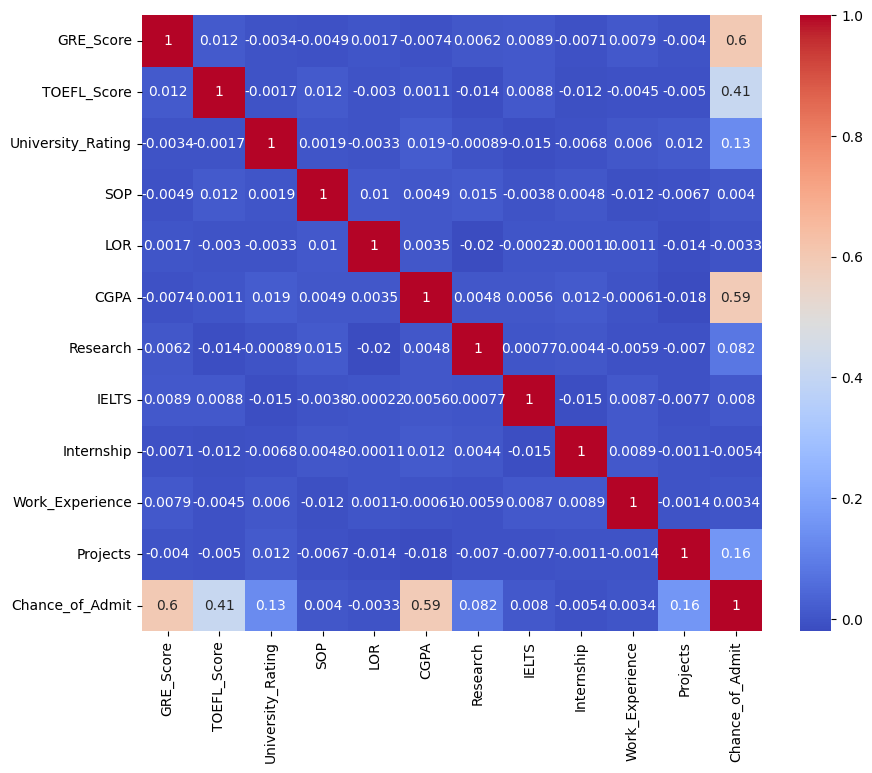

In [23]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

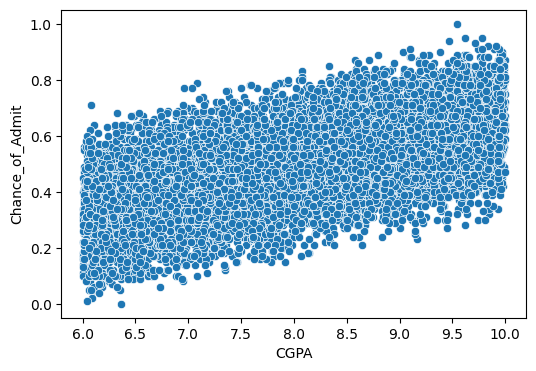

In [24]:
#CGPA vs Chance of Admit
plt.figure(figsize=(6,4))
sns.scatterplot(x="CGPA",y="Chance_of_Admit",data=df)
plt.show()

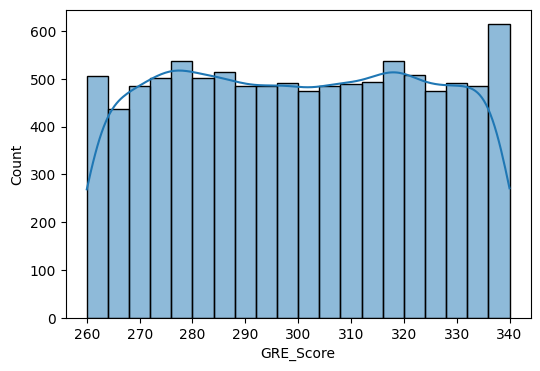

In [25]:
#GRE Score Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["GRE_Score"],bins=20,kde=True)
plt.show()


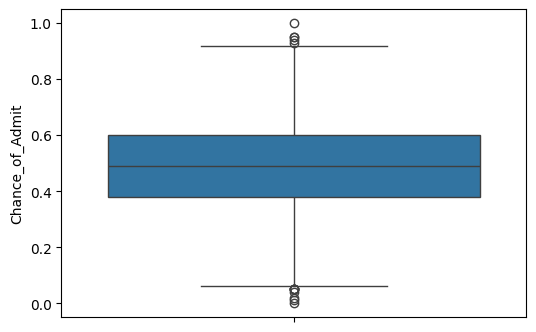

In [26]:
#Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Chance_of_Admit"])
plt.show()

In [27]:
#Train Model
X=df.drop("Chance_of_Admit",axis=1)

y=df["Chance_of_Admit"]

In [28]:
#Scaling

scaler=StandardScaler()

X=scaler.fit_transform(X)

In [29]:
#Split Data
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [30]:
#Train Linear Regression
model=LinearRegression()

model.fit(X_train,y_train)


LinearRegression()

In [31]:
#Prediction

y_pred=model.predict(X_test)

In [32]:
#Accuracy
print("MAE :",mean_absolute_error(y_test,y_pred))

print("MSE :",mean_squared_error(y_test,y_pred))

print("RMSE :",np.sqrt(mean_squared_error(y_test,y_pred)))

print("R2 Score :",r2_score(y_test,y_pred))

MAE : 0.03239316366584423
MSE : 0.0016438689893273847
RMSE : 0.040544654263261204
R2 Score : 0.934611226882699


In [33]:
#Save Model
pickle.dump(model,open("model.pkl","wb"))

pickle.dump(scaler,open("scaler.pkl","wb"))

print("Model Saved Successfully!")


Model Saved Successfully!


In [34]:
#Load Model (Testing)
model=pickle.load(open("model.pkl","rb"))

scaler=pickle.load(open("scaler.pkl","rb"))